In [1]:
# ¿Qué tan confiables son las probabilidades de default estimadas y cómo cambia su comportamiento al variar el umbral de clasificación?

# Este archivo es una simulación didáctica controlada de predicciones fuera de muestra; permite estudiar calibración sin representar solicitantes ni una política real de crédito.

import matplotlib.pyplot as plt
import pandas as pd

predictions = pd.read_csv("../data/risk_predictions.csv").rename(columns={"sex": "group_code"})
predictions["probability_band"] = pd.cut(
    predictions["default_probability"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
    include_lowest=True,
)
calibration = (
    predictions.groupby("probability_band", observed=True)
    .agg(
        applications=("application_id", "size"),
        mean_probability=("default_probability", "mean"),
        observed_default_rate=("observed_default", "mean"),
    )
    .reset_index()
)
calibration

,probability_band,applications,mean_probability,observed_default_rate
0,"(-0.001, 0.2]",760,0.152117,0.096053
1,"(0.2, 0.4]",2607,0.314143,0.126582
2,"(0.4, 0.6]",4039,0.491177,0.152265
3,"(0.6, 0.8]",1170,0.708616,0.489744
4,"(0.8, 1.0]",424,0.856330,0.750000


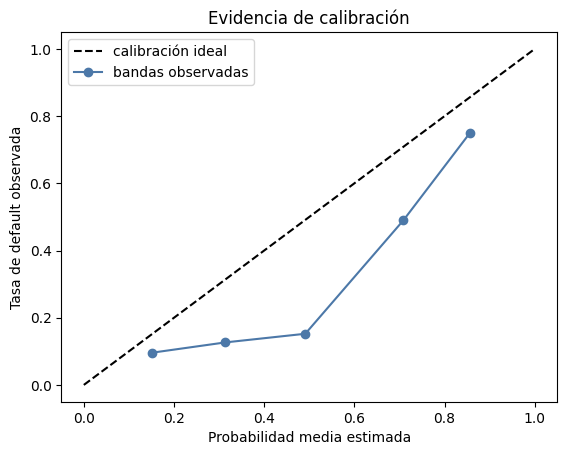

In [2]:
# La diagonal permite contrastar una probabilidad declarada con la frecuencia observada en cada banda.

plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="calibración ideal")
plt.plot(
    calibration["mean_probability"],
    calibration["observed_default_rate"],
    marker="o",
    color="#4c78a8",
    label="bandas observadas",
)
plt.xlabel("Probabilidad media estimada")
plt.ylabel("Tasa de default observada")
plt.title("Evidencia de calibración")
plt.legend()
plt.show()

In [3]:
# El umbral define un punto operativo del clasificador; sus costos ilustran consecuencias de error, no una política de crédito.

cost_false_negative = 10
cost_false_positive = 1
rows = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    priority = predictions["default_probability"] >= threshold
    false_negative = ((~priority) & (predictions["observed_default"] == 1)).sum()
    false_positive = (priority & (predictions["observed_default"] == 0)).sum()
    rows.append(
        {
            "threshold": threshold,
            "prioritized_applications": priority.sum(),
            "false_negative": false_negative,
            "false_positive": false_positive,
            "expected_cost": cost_false_negative * false_negative + cost_false_positive * false_positive,
        }
    )

tradeoff = pd.DataFrame(rows)
tradeoff

,threshold,prioritized_applications,false_negative,false_positive,expected_cost
0,0.2,8240,73,6404,7134
1,0.3,7279,182,5552,7372
2,0.4,5633,403,4127,8157
3,0.5,3371,694,2156,9096
4,0.6,1594,1018,703,10883


In [4]:
# La revisión por grupo permite detectar una diferencia que merece análisis adicional; no determina por sí sola una regla de decisión.

selected_threshold = tradeoff.loc[tradeoff["expected_cost"].idxmin(), "threshold"]
predictions["prioritized"] = predictions["default_probability"] >= selected_threshold
group_review = (
    predictions.groupby("group_code")
    .agg(
        applications=("application_id", "size"),
        observed_default_rate=("observed_default", "mean"),
        prioritization_rate=("prioritized", "mean"),
        mean_probability=("default_probability", "mean"),
    )
    .reset_index()
)
group_review

,group_code,applications,observed_default_rate,prioritization_rate,mean_probability
0,1,3585,0.231520,0.934728,0.480708
1,2,5415,0.199261,0.902862,0.440863


In [5]:
# Se conservan los elementos necesarios para auditar la calibración, el punto operativo y la revisión de grupos.

from pathlib import Path

output = Path("../submission")
calibration.to_csv(output / "calibration_summary.csv", index=False)
tradeoff.to_csv(output / "threshold_tradeoff.csv", index=False)
group_review.to_csv(output / "group_review.csv", index=False)